<a href="https://colab.research.google.com/github/dsdskm/ai/blob/data_finance/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 라이브러리 설치 및 로드

In [24]:
!pip install -q finance-datareader
import FinanceDataReader as fdr
import seaborn as sns


# plt 초기화

In [167]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = (14,8)
plt.rcParams['font.size'] = 16
plt.rcParams['lines.linewidth'] = 2
plt.rcParams["axes.grid"] = True
plt.rcParams['axes.axisbelow'] = True

# 날짜 범위 설정(2020-01-01~Today)

In [259]:
from datetime import date
start_date = "2020-01-01"
today_date = date.today()

# 매그니피센트7 종목 샘플 코드
## 애플, 아마존, 알파벳, 메타, 마이크로소프트, 엔비디아, 테슬라

<Axes: >

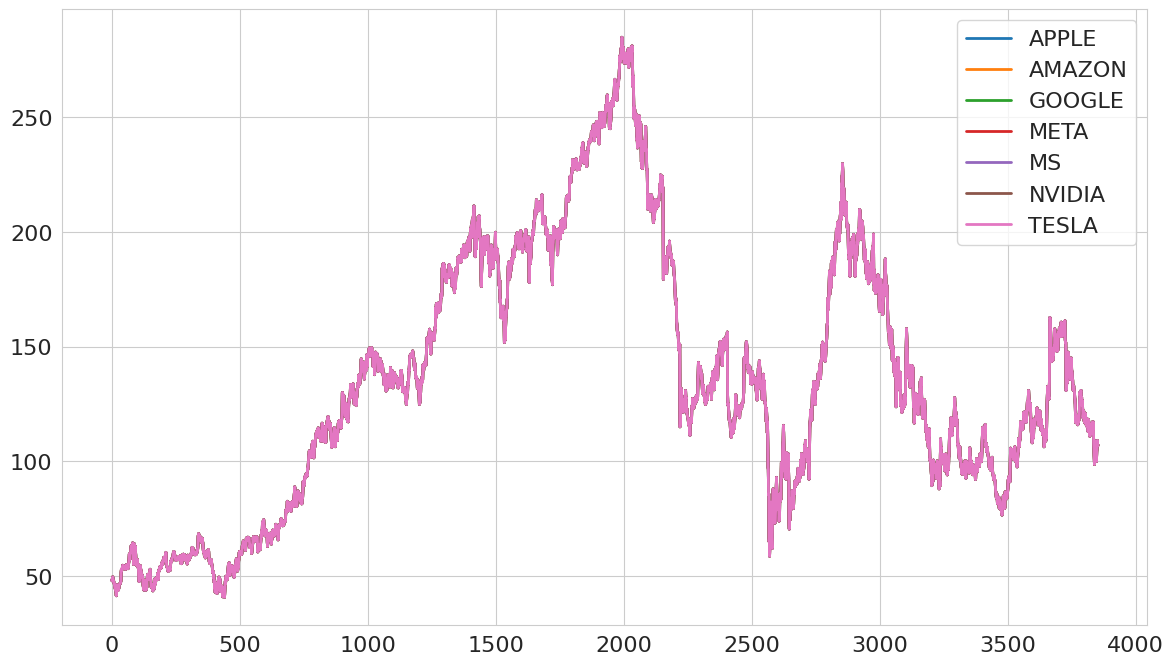

In [263]:


def getDataFrame(code):
  # Open: 시가
  # High: 고가
  # Low: 저가
  # Close: 종가
  # Volume: 거래량
  # Change: 전일대비 등락
  # Amount: 거래대금
  # Stocks: 상장주식수
  # FaceValue: 액면가
  # StandardPrice: 기준가
  # StopOrder: 거래정지 여부(Y/N)
  # Issues: 관리종목 여부(Y/N)
  # https://github.com/FinanceData/FinanceDataReader/wiki/Quick-Start

  df_ret = fdr.DataReader(code, start_date, today_date)
  # 원하는 컬럼만 설정
  df_ret = df[["Close","Volume"]]
  return df_ret

# 애플
df_aapl = getDataFrame("AAPL")
# 아마존
df_amzn = getDataFrame("AMZN")
# 알파벳(구글)
df_google = getDataFrame("GOOGL")
# 메타
df_meta = getDataFrame("META")
# 마이크로소프트
df_msft = getDataFrame("MSFT")
# 엔비디아
df_nvda = getDataFrame("NVDA")
# 테슬라
df_tsla = getDataFrame("TSLA")
# S&P500
df_snp500 = getDataFrame("S&P500")
import pandas as pd
df_plot = pd.DataFrame()

# df_plot['S&P500'] = df_snp500['Close']
df_plot['APPLE'] = df_aapl['Close']
df_plot['AMAZON'] = df_amzn['Close']
df_plot['GOOGLE'] = df_google['Close']
df_plot['META'] = df_meta['Close']
df_plot['MS'] = df_msft['Close']
df_plot['NVIDIA'] = df_nvda['Close']
df_plot['TESLA'] = df_tsla['Close']

df_plot.plot()

S&P500 종목 가격 저장

In [264]:
# 디렉토리가 없으면 생성
import os
import csv
import pandas as pd
folder = "sp500_price"
if not os.path.isdir(folder):
    os.mkdir(folder)


sp500 = fdr.StockListing("S&P500")
print("working started")
for ix, row in sp500.iterrows():
    sym, name = row['Symbol'], row['Name']
    csv_fn = os.path.join(folder, f'{sym}.csv')
    if os.path.exists(csv_fn):
      os.remove(csv_fn)
    if sym=="BRKB" or sym=="BFB":
      continue
    try:
      print(csv_fn,ix, end=' ')
      df = fdr.DataReader(sym, start_date, today_date)
      df['Symbol'] = sym
      print(len(df), 'rows')
      df.to_csv(csv_fn, quoting=csv.QUOTE_MINIMAL)
    except ValueError as e:
      print(e)
      continue
    except IndexError as e:
      print(e)
      continue
print("working completed")

working started
sp500_price/MMM.csv 0 1338 rows
sp500_price/AOS.csv 1 1338 rows
sp500_price/ABT.csv 2 1338 rows
sp500_price/ABBV.csv 3 1338 rows
sp500_price/ACN.csv 4 1338 rows
sp500_price/ADBE.csv 5 1338 rows
sp500_price/AMD.csv 6 1338 rows
sp500_price/AES.csv 7 1338 rows
sp500_price/AFL.csv 8 1338 rows
sp500_price/A.csv 9 1338 rows
sp500_price/APD.csv 10 1338 rows
sp500_price/ABNB.csv 11 1100 rows
sp500_price/AKAM.csv 12 1338 rows
sp500_price/ALB.csv 13 1338 rows
sp500_price/ARE.csv 14 1338 rows
sp500_price/ALGN.csv 15 1338 rows
sp500_price/ALLE.csv 16 1338 rows
sp500_price/LNT.csv 17 1338 rows
sp500_price/ALL.csv 18 1338 rows
sp500_price/GOOGL.csv 19 1338 rows
sp500_price/GOOG.csv 20 1338 rows
sp500_price/MO.csv 21 1338 rows
sp500_price/AMZN.csv 22 1338 rows
sp500_price/AMCR.csv 23 1338 rows
sp500_price/AEE.csv 24 1338 rows
sp500_price/AEP.csv 25 1338 rows
sp500_price/AXP.csv 26 1338 rows
sp500_price/AIG.csv 27 1338 rows
sp500_price/AMT.csv 28 1338 rows
sp500_price/AWK.csv 29 1338 r

# 매월 첫번째 개장일 가격과 필요한 컬럼만 남도록 변환

In [268]:
# prompt: concat을 사용해서 read_csv 호출하는 법 알려줘

import pandas as pd
import os

# ... (previous code)

# S&P500 전체 종목 가격
folder = "sp500_price"
df_price = pd.DataFrame()

for filename in os.listdir(folder):
    if filename.endswith(".csv"):
        filepath = os.path.join(folder, filename)
        try:
            # Use concat to efficiently combine dataframes
            df = pd.read_csv(filepath)
            df_price = pd.concat([df_price, df], ignore_index=True)
        except pd.errors.EmptyDataError:
            print(f"Warning: Empty file - {filename}, skipping.")
        except pd.errors.ParserError:
            print(f"Warning: Parsing error - {filename}, skipping.")


# Unnamed column 네이밍
df_price = df_price.rename(columns={"Unnamed: 0":"Date"})
# datetime index 지정
df_price['Date'] = pd.to_datetime(df_price['Date'])
# 불필요 컬럼 제거
df_price = df_price.drop(['Open','High','Low','Adj Close'], axis=1)

df_price

,Date,Close,Volume,Symbol
0,2020-01-02,36.299999,4979300,EBAY
1,2020-01-03,35.959999,3960900,EBAY
2,2020-01-06,35.779999,5866000,EBAY
3,2020-01-07,35.619999,6867400,EBAY
4,2020-01-08,35.599998,6072600,EBAY
...,...,...,...,...
662971,2025-04-23,105.559998,597500,MHK
662972,2025-04-24,109.099998,715400,MHK
662973,2025-04-25,106.870003,925200,MHK
662974,2025-04-28,106.769997,591500,MHK


# 월 별 수익률 계산

In [273]:
df_price_month = df_price.groupby(["Symbol",df_price['Date'].dt.year, df_price['Date'].dt.month]).first()
df_price_month['Monthly_Return'] = df_price_month.groupby('Symbol')['Close'].pct_change()

df_price_month

Date       Close   Volume  Monthly_Return
Symbol Date Date                                                
A      2020 1    2020-01-02   85.949997  1410500             NaN
            2    2020-02-03   82.150002  1919800       -0.044212
            3    2020-03-02   81.970001  3407500       -0.002191
            4    2020-04-01   68.919998  2173600       -0.159205
            5    2020-05-01   74.209999  1618600        0.076756
...                     ...         ...      ...             ...
ZTS    2024 12   2024-12-02  176.809998  2391500       -0.028250
       2025 1    2025-01-02  162.610001  2232800       -0.080312
            2    2025-02-03  171.940002  2602000        0.057377
            3    2025-03-03  170.529999  3020200       -0.008201
            4    2025-04-01  161.910004  2735000       -0.050548

[31717 rows x 4 columns]

# 년도 별 수익률 계산

In [275]:
df_price_year = df_price.groupby(["Symbol",df_price['Date'].dt.year]).first()
df_price_year['Yearly_Return'] = df_price_year.groupby('Symbol')['Close'].pct_change()

df_price_year

Date       Close   Volume  Yearly_Return
Symbol Date                                               
A      2020 2020-01-02   85.949997  1410500            NaN
       2021 2021-01-04  118.639999  2030700       0.380337
       2022 2022-01-03  156.479996  1606300       0.318948
       2023 2023-01-03  150.039993  1414300      -0.041155
       2024 2024-01-02  138.750000  1441600      -0.075247
...                ...         ...      ...            ...
ZTS    2021 2021-01-04  163.589996  1805900       0.219547
       2022 2022-01-03  234.029999  2772700       0.430589
       2023 2023-01-03  146.850006  1840600      -0.372516
       2024 2024-01-02  196.570007  1642300       0.338577
       2025 2025-01-02  162.610001  2232800      -0.172763

[2983 rows x 4 columns]

# 데이터 저장

In [277]:
# prompt: df_price_year 내용 csv로 다운로드 받는 코드 알려줘

# Assuming df_price_year is already defined as in your provided code.

from google.colab import files

df_price_year.to_csv('df_price_year.csv', encoding='utf-8-sig') # encoding='utf-8-sig' for proper Excel compatibility
files.download('df_price_year.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>